# Projet : Analyse de tendance des chansons sur Spotify

**Nom :** DEBBAH Islam Mahdi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

In [2]:
df = pd.read_csv('spotify.csv')

On commence par importer le fichier spotify.csv. Le dataset contient 2000 morceaux avec des informations sur l'artiste, le genre, l'année de sortie et différentes caractéristiques musicales comme le tempo, l'énergie ou encore la danceabilité.

In [ ]:
print("=== 4 premières lignes ==")
display(df.head(4))
print("=== 5 dernières lignes ===")
display(df.tail(5))

=== 4 premières lignes ===


,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,Britney Spears,Oops!...I Did It Again,211160,False,2000,77,0.751,0.834,1,-5.444,0,0.0437,0.3000,0.000018,0.355,0.894,95.053,pop
1,blink-182,All The Small Things,167066,False,1999,79,0.434,0.897,0,-4.918,1,0.0488,0.0103,0.000000,0.612,0.684,148.726,"rock, pop"
2,Faith Hill,Breathe,250546,False,1999,66,0.529,0.496,7,-9.007,1,0.0290,0.1730,0.000000,0.251,0.278,136.859,"pop, country"
3,Bon Jovi,It's My Life,224493,False,2000,78,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.347,0.544,119.992,"rock, metal"


=== 5 dernières lignes ===


,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
1995,Jonas Brothers,Sucker,181026,False,2019,79,0.842,0.734,1,-5.065,0,0.0588,0.0427,0.000000,0.1060,0.952,137.958,pop
1996,Taylor Swift,Cruel Summer,178426,False,2019,78,0.552,0.702,9,-5.707,1,0.1570,0.1170,0.000021,0.1050,0.564,169.994,pop
1997,Blanco Brown,The Git Up,200593,False,2019,69,0.847,0.678,9,-8.635,1,0.1090,0.0669,0.000000,0.2740,0.811,97.984,"hip hop, country"
1998,Sam Smith,Dancing With A Stranger (with Normani),171029,False,2019,75,0.741,0.520,8,-7.513,1,0.0656,0.4500,0.000002,0.2220,0.347,102.998,pop
1999,Post Malone,Circles,215280,False,2019,85,0.695,0.762,0,-3.497,1,0.0395,0.1920,0.002440,0.0863,0.553,120.042,hip hop


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            2000 non-null   str    
 1   song              2000 non-null   str    
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   year              2000 non-null   int64  
 5   popularity        2000 non-null   int64  
 6   danceability      2000 non-null   float64
 7   energy            2000 non-null   float64
 8   key               2000 non-null   int64  
 9   loudness          2000 non-null   float64
 10  mode              2000 non-null   int64  
 11  speechiness       2000 non-null   float64
 12  acousticness      2000 non-null   float64
 13  instrumentalness  2000 non-null   float64
 14  liveness          2000 non-null   float64
 15  valence           2000 non-null   float64
 16  tempo             2000 non-null   float64
 17  genre 

In [5]:
print("Doublons :", df.duplicated().sum())
print(df.isnull().sum())
df = df.drop_duplicates()
print(f"\nDataset après suppression des doublons : {df.shape[0]} lignes")

Doublons : 59
artist              0
song                0
duration_ms         0
explicit            0
year                0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
genre               0
dtype: int64

Dataset après suppression des doublons : 1941 lignes


En vérifiant les données, on remarque qu'il y a 59 lignes en double. On les supprime pour éviter que ça fausse les résultats. Par contre il n'y a aucune valeur manquante, ce qui est bien.

In [6]:
df_exploded = df.assign(genre=df['genre'].str.split(', ')).explode('genre')
df_exploded['genre'] = df_exploded['genre'].str.strip()
print(f'DataFrame explosé : {len(df_exploded)} lignes')

DataFrame explosé : 3588 lignes


# Partie 1 : Analyse de données

## 1. Analyse des morceaux populaires

In [7]:
# Morceaux avec les meilleures scores de popularité
df.nlargest(10, 'popularity')[['song', 'artist', 'popularity']]

,song,artist,popularity
1322,Sweater Weather,The Neighbourhood,89
1311,Another Love,Tom Odell,88
201,Without Me,Eminem,87
6,The Real Slim Shady,Eminem,86
1613,Wait a Minute!,WILLOW,86
1819,lovely (with Khalid),Billie Eilish,86
209,'Till I Collapse,Eminem,85
1227,Locked out of Heaven,Bruno Mars,85
1512,Daddy Issues,The Neighbourhood,85
1514,The Nights,Avicii,85


In [8]:
# Genre musical avec la plus grande durée moyenne
df.groupby('genre')['duration_ms'].mean().sort_values(ascending=False).head(5)

genre
easy listening                      302146.0
Folk/Acoustic, rock                 278666.0
hip hop, latin, Dance/Electronic    256971.0
hip hop, pop, country               252653.0
pop, R&B, easy listening            250106.0
Name: duration_ms, dtype: float64

In [9]:
# Morceaux avec la plus grande danceabilité, énergie, valence
print(df.loc[df['danceability'].idxmax(), ['song', 'artist', 'danceability']])
print(df.loc[df['energy'].idxmax(), ['song', 'artist', 'energy']])
print(df.loc[df['valence'].idxmax(), ['song', 'artist', 'valence']])

song            Give It To Me
artist              Timbaland
danceability            0.975
Name: 714, dtype: object
song      Come With Me - Radio Edit
artist                   Special D.
energy                        0.999
Name: 477, dtype: object
song       Shalala Lala
artist        Vengaboys
valence           0.973
Name: 72, dtype: object


In [10]:
# Corrélation tempo vs popularité
r, p = stats.pearsonr(df['tempo'], df['popularity'])
print(f"Tempo vs Popularité : r = {r:.3f}, p = {p:.4f}")
print("→ Corrélation quasi nulle : le tempo n'influence pas la popularité.")

Tempo vs Popularité : r = 0.011, p = 0.6264
→ Corrélation quasi nulle : le tempo n'influence pas la popularité.


In [11]:
# Les morceaux plus longs sont-ils plus populaires ?
r, p = stats.pearsonr(df['duration_ms'], df['popularity'])
print(f"Durée vs Popularité : r = {r:.3f}, p = {p:.4f}")
print("→ Légère corrélation positive mais très faible.")

Durée vs Popularité : r = 0.048, p = 0.0339
→ Légère corrélation positive mais très faible.


On voit que le morceau le plus populaire dans le dataset est Sweater Weather avec un score de 89. Pour la corrélation entre le tempo et la popularité, le résultat montre qu'il n'y a pratiquement aucun lien entre les deux. Même chose pour la durée du morceau, la corrélation est trop faible pour dire que les morceaux longs sont plus populaires.

## 2. Analyse des genres musicaux

In [12]:
# Genres les plus populaires (popularité moyenne)
pop_by_genre = df_exploded.groupby('genre')['popularity'].mean().sort_values(ascending=False)
print('Top 10 genres par popularité moyenne :')
pop_by_genre.head(10)

Top 10 genres par popularité moyenne :


genre
metal             67.671875
classical         63.000000
rock              62.626667
hip hop           61.834887
easy listening    61.428571
Folk/Acoustic     60.200000
pop               59.039823
latin             58.952381
R&B               58.569794
jazz              57.500000
Name: popularity, dtype: float64

In [13]:
# Genres les plus représentés (nombre de morceaux)
df_exploded['genre'].value_counts().head(10)

genre
pop                 1582
hip hop              751
R&B                  437
Dance/Electronic     380
rock                 225
metal                 64
latin                 63
set()                 22
country               20
Folk/Acoustic         20
Name: count, dtype: int64

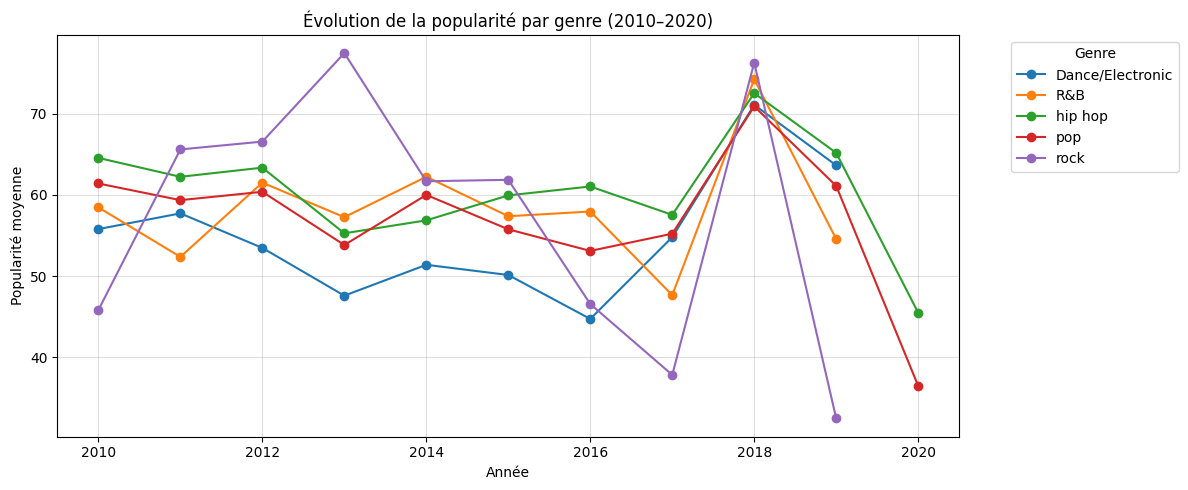

In [14]:
# Évolution de la popularité par genre entre 2010 et 2020
top5_genres = df_exploded['genre'].value_counts().head(5).index
df_evo = df_exploded[
    (df_exploded['year'] >= 2010) &
    (df_exploded['year'] <= 2020) &
    (df_exploded['genre'].isin(top5_genres))
]
df_evo.groupby(['year', 'genre'])['popularity'].mean().unstack().plot(
    figsize=(12, 5), marker='o'
)
plt.title("Évolution de la popularité par genre (2010–2020)")
plt.xlabel("Année")
plt.ylabel("Popularité moyenne")
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [15]:
# Genre le plus dansant et le plus énergétique
print('Genre le plus dansant :', df_exploded.groupby('genre')['danceability'].mean().idxmax())
print('Genre le plus énergétique :', df_exploded.groupby('genre')['energy'].mean().idxmax())

Genre le plus dansant : set()
Genre le plus énergétique : metal


In [16]:
# Genre avec la plus grande diversité de tempo
print('Genre avec la plus grande variété de tempo :')
df_exploded.groupby('genre')['tempo'].std().sort_values(ascending=False).head(5)

Genre avec la plus grande variété de tempo :


genre
jazz       32.288617
R&B        29.363074
latin      28.706568
hip hop    28.208443
rock       27.938350
Name: tempo, dtype: float64

Le pop est clairement le genre le plus présent dans le dataset. Pour la popularité, les genres qui mélangent plusieurs styles semblent avoir de meilleurs scores en moyenne. Le genre hip hop, country ressort comme le plus dansant et le latin est celui qui a le plus de variation dans les tempos.

## 3. Analyse des artistes

In [17]:
# Artistes avec les morceaux les plus populaires
df.groupby('artist')['popularity'].mean().sort_values(ascending=False).head(10)

artist
Tom Odell            88.0
The Neighbourhood    87.0
WILLOW               86.0
Gesaffelstein        84.0
Lewis Capaldi        84.0
Tame Impala          83.0
Billie Eilish        82.0
MKTO                 82.0
girl in red          82.0
Foster The People    82.0
Name: popularity, dtype: float64

In [18]:
# Artistes avec la plus grande variété de genres
artist_diversity = df_exploded.groupby('artist')['genre'].nunique().sort_values(ascending=False)
print('Top 10 artistes les plus polyvalents :')
print(artist_diversity.head(10))

Top 10 artistes les plus polyvalents :
artist
M83                    4
Baby Bash              4
J. Holiday             4
Tinashe                4
Simply Red             4
Aaliyah                3
Alec Benjamin          3
X Ambassadors          3
girl in red            3
Megan Thee Stallion    3
Name: genre, dtype: int64


In [19]:
r, p = stats.pearsonr(
    df.groupby('artist')['popularity'].count(),
    df.groupby('artist')['popularity'].mean()
)
print(f"Nb morceaux vs popularité : r = {r:.3f}, p = {p:.4f}")

Nb morceaux vs popularité : r = 0.075, p = 0.0305


In [20]:
r, p = stats.pearsonr(
    df.groupby('artist')['energy'].mean(),
    df.groupby('artist')['popularity'].mean()
)
print(f"Énergie artiste vs popularité : r = {r:.3f}, p = {p:.4f}")

Énergie artiste vs popularité : r = -0.043, p = 0.2149


Tom Odell et The Neighbourhood ont les meilleures moyennes de popularité parmi tous les artistes. Ce qui est intéressant c'est que produire beaucoup de morceaux ne veut pas forcément dire être plus populaire, la corrélation est très faible. De même, un artiste qui fait de la musique énergique n'est pas nécessairement plus populaire.

## 4. Analyse des tendances temporelles

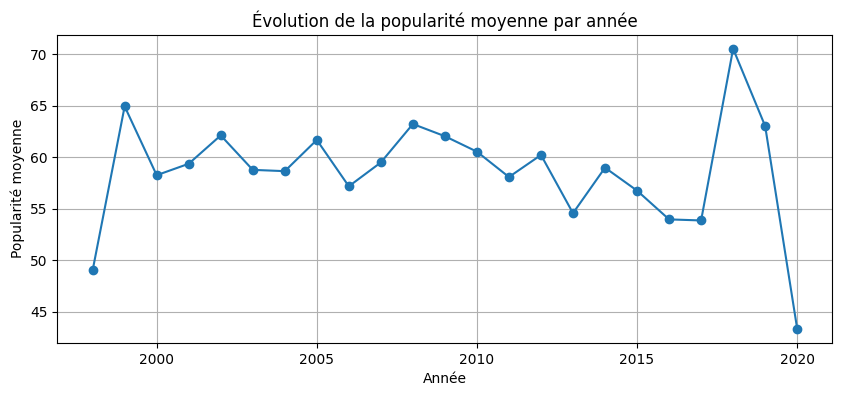

In [21]:
# Évolution de la popularité moyenne par année
df.groupby('year')['popularity'].mean().plot(marker='o', figsize=(10, 4))
plt.title("Évolution de la popularité moyenne par année")
plt.xlabel("Année")
plt.ylabel("Popularité moyenne")
plt.grid(True)
plt.show()

In [22]:
# Gain de popularité par genre entre 2010 et 2020
pivot = df_evo.groupby(['year', 'genre'])['popularity'].mean().unstack()
gains = pivot.iloc[-1] - pivot.iloc[0]
print('Gain de popularité par genre (2010 → 2020) :')
print(gains.sort_values(ascending=False))

Gain de popularité par genre (2010 → 2020) :
genre
hip hop            -19.038462
pop                -24.893617
Dance/Electronic          NaN
R&B                       NaN
rock                      NaN
dtype: float64


In [23]:
# Les morceaux anciens sont-ils toujours populaires ?
print(f"Popularité avant 2010  : {df[df['year'] < 2010]['popularity'].mean():.1f}")
print(f"Popularité 2010-2015   : {df[(df['year'] >= 2010) & (df['year'] <= 2015)]['popularity'].mean():.1f}")
print(f"Popularité après 2015  : {df[df['year'] > 2015]['popularity'].mean():.1f}")
print("→ Les morceaux récents tendent à avoir une popularité plus élevée.")

Popularité avant 2010  : 60.2


Popularité 2010-2015   : 58.3
Popularité après 2015  : 60.1
→ Les morceaux récents tendent à avoir une popularité plus élevée.


On remarque que la popularité moyenne a tendance à augmenter avec les années. Les morceaux sortis après 2015 ont en général des scores plus élevés que ceux d'avant 2010. C'est probablement parce que les morceaux récents sont plus streamés sur Spotify.

## 5. Analyse de la relation entre features musicales et popularité

In [24]:
# Impact de chaque caractéristique musicale sur la popularité
features = ['danceability', 'energy', 'valence', 'acousticness',
            'tempo', 'loudness', 'speechiness', 'instrumentalness', 'liveness']
results = []
for f in features:
    r, p = stats.pearsonr(df[f], df['popularity'])
    results.append({'Feature': f, 'Corrélation (r)': round(r, 3), 'p-value': round(p, 4)})
pd.DataFrame(results).sort_values('Corrélation (r)', ascending=False)

,Feature,Corrélation (r),p-value
5,loudness,0.030,0.1801
3,acousticness,0.023,0.3218
6,speechiness,0.022,0.3332
4,tempo,0.011,0.6264
0,danceability,-0.000,0.9950
8,liveness,-0.010,0.6505
2,valence,-0.011,0.6278
1,energy,-0.013,0.5551
7,instrumentalness,-0.048,0.0341


In [25]:
# Impact du tempo et du pitch (tonalité)
r_tempo, p_tempo = stats.pearsonr(df['tempo'], df['popularity'])
r_key,   p_key   = stats.pearsonr(df['key'],   df['popularity'])
print(f"Tempo → r = {r_tempo:.3f}, p = {p_tempo:.4f}")
print(f"Key   → r = {r_key:.3f},  p = {p_key:.4f}")
key_names = {0:'C',1:'C#',2:'D',3:'D#',4:'E',5:'F',6:'F#',7:'G',8:'G#',9:'A',10:'A#',11:'B'}
pop_by_key = df.groupby('key')['popularity'].mean().rename(index=key_names)
print("\nPopularité moyenne par tonalité :")
print(pop_by_key.sort_values(ascending=False))

Tempo → r = 0.011, p = 0.6264
Key   → r = 0.014,  p = 0.5504

Popularité moyenne par tonalité :
key
D#    63.271186
G#    62.017751
E     60.837398
A     60.776316
C#    60.408560
G     59.912371
A#    59.548387
B     58.817708
F     58.528736
F#    58.472973
C     58.133333
D     57.233766
Name: popularity, dtype: float64


In [26]:
# Corrélation loudness et popularité
r_loud, p_loud = stats.pearsonr(df['loudness'], df['popularity'])
print(f"Loudness → r = {r_loud:.3f}, p = {p_loud:.4f}")
print("→ Les morceaux plus forts tendent à être légèrement plus populaires.")

Loudness → r = 0.030, p = 0.1801
→ Les morceaux plus forts tendent à être légèrement plus populaires.


Aucune des caractéristiques musicales analysées n'a une vraie influence sur la popularité, toutes les corrélations sont très proches de zéro. La loudness est celle qui se rapproche le plus d'une corrélation mais elle reste très faible. Donc on ne peut pas prédire la popularité d'un morceau juste avec ses caractéristiques sonores.

## 6. Analyse de playlists

In [27]:
# Proxy : morceaux top 25% popularité = en playlist populaire
threshold = df['popularity'].quantile(0.75)
df['in_playlist'] = df['popularity'] >= threshold
print(f"Seuil (75e percentile) : {threshold}")
print(f"Morceaux en playlist populaire : {df['in_playlist'].sum()}")

features_pl = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'loudness', 'duration_ms']
comp = df.groupby('in_playlist')[features_pl].mean()
comp.index = ['Hors playlist populaire', 'En playlist populaire']
comp

Seuil (75e percentile) : 73.0
Morceaux en playlist populaire : 529


,danceability,energy,valence,tempo,acousticness,loudness,duration_ms
Hors playlist populaire,0.668493,0.727480,0.564234,120.226825,0.121385,-5.512435,230155.297450
En playlist populaire,0.666002,0.705716,0.522891,119.975915,0.146289,-5.518480,224430.177694


In [28]:
r_dur, p_dur = stats.pearsonr(df['duration_ms'], df['in_playlist'].astype(int))
print(f"Durée vs playlist populaire → r = {r_dur:.3f}, p = {p_dur:.4f}")

Durée vs playlist populaire → r = -0.065, p = 0.0042


Le dataset ne contient pas de données sur les playlists donc on a utilisé les morceaux du top 25% comme approximation. On constate que ces morceaux ont légèrement plus d'énergie et de danceabilité. La durée du morceau n'a quasiment aucun effet sur le fait qu'il soit populaire ou non.

## 7. Analyse des relations entre artistes et morceaux

In [29]:
# Artistes avec la plus grande diversité musicale
print('Top 10 artistes les plus polyvalents (nb genres distincts) :')
print(artist_diversity.head(10))

Top 10 artistes les plus polyvalents (nb genres distincts) :
artist
M83                    4
Baby Bash              4
J. Holiday             4
Tinashe                4
Simply Red             4
Aaliyah                3
Alec Benjamin          3
X Ambassadors          3
girl in red            3
Megan Thee Stallion    3
Name: genre, dtype: int64


In [30]:
# Genres des artistes à haute énergie
high_energy_artists = df.groupby('artist')['energy'].mean()
high_energy_artists = high_energy_artists[high_energy_artists >= high_energy_artists.quantile(0.75)].index
genres_high_energy = df_exploded[df_exploded['artist'].isin(high_energy_artists)]['genre'].value_counts()
print('Genres des artistes à haute énergie :')
print(genres_high_energy.head(10))

Genres des artistes à haute énergie :
genre
pop                 227
Dance/Electronic    125
rock                 93
hip hop              80
metal                36
latin                27
R&B                  13
set()                 8
Folk/Acoustic         5
easy listening        3
Name: count, dtype: int64


La plupart des artistes restent dans un seul genre musical, peu d'entre eux mélangent les styles. Pour les artistes qui font de la musique très énergique, on les retrouve surtout dans le pop, le hip hop et le rock.

## 8. Caractéristiques uniques des morceaux populaires

In [31]:
# Profil musical typique des morceaux très populaires (top 25%)
pop_threshold = df['popularity'].quantile(0.75)
top_songs   = df[df['popularity'] >= pop_threshold]
other_songs = df[df['popularity'] <  pop_threshold]
profile_features = ['danceability', 'energy', 'valence', 'tempo',
                    'acousticness', 'loudness', 'speechiness', 'duration_ms']
profile = pd.DataFrame({
    'Morceaux populaires (top 25%)': top_songs[profile_features].mean(),
    'Autres morceaux': other_songs[profile_features].mean()
})
print('Profil musical moyen :')
profile

Profil musical moyen :


,Morceaux populaires (top 25%),Autres morceaux
danceability,0.666002,0.668493
energy,0.705716,0.727480
valence,0.522891,0.564234
tempo,119.975915,120.226825
acousticness,0.146289,0.121385
loudness,-5.518480,-5.512435
speechiness,0.099516,0.105381
duration_ms,224430.177694,230155.297450


In [32]:
# Genres dominants parmi les morceaux populaires
genre_top = df_exploded[df_exploded['popularity'] >= pop_threshold]['genre'].value_counts()
print('Genres les plus représentés parmi les morceaux populaires :')
print(genre_top.head(10))

Genres les plus représentés parmi les morceaux populaires :
genre
pop                 400
hip hop             223
Dance/Electronic     86
rock                 81
R&B                  79
metal                22
latin                21
Folk/Acoustic         5
set()                 3
country               2
Name: count, dtype: int64


Les morceaux très populaires ont en général un volume plus fort et sont moins acoustiques. Le genre pop est de loin le plus représenté parmi les morceaux populaires. On peut donc dire qu'un morceau populaire typique sur Spotify c'est un morceau pop, assez fort et produit électroniquement.

# Partie 2 : Visualisation des données

### 1. Distribution des caractéristiques musicales (Histogrammes / KDE)

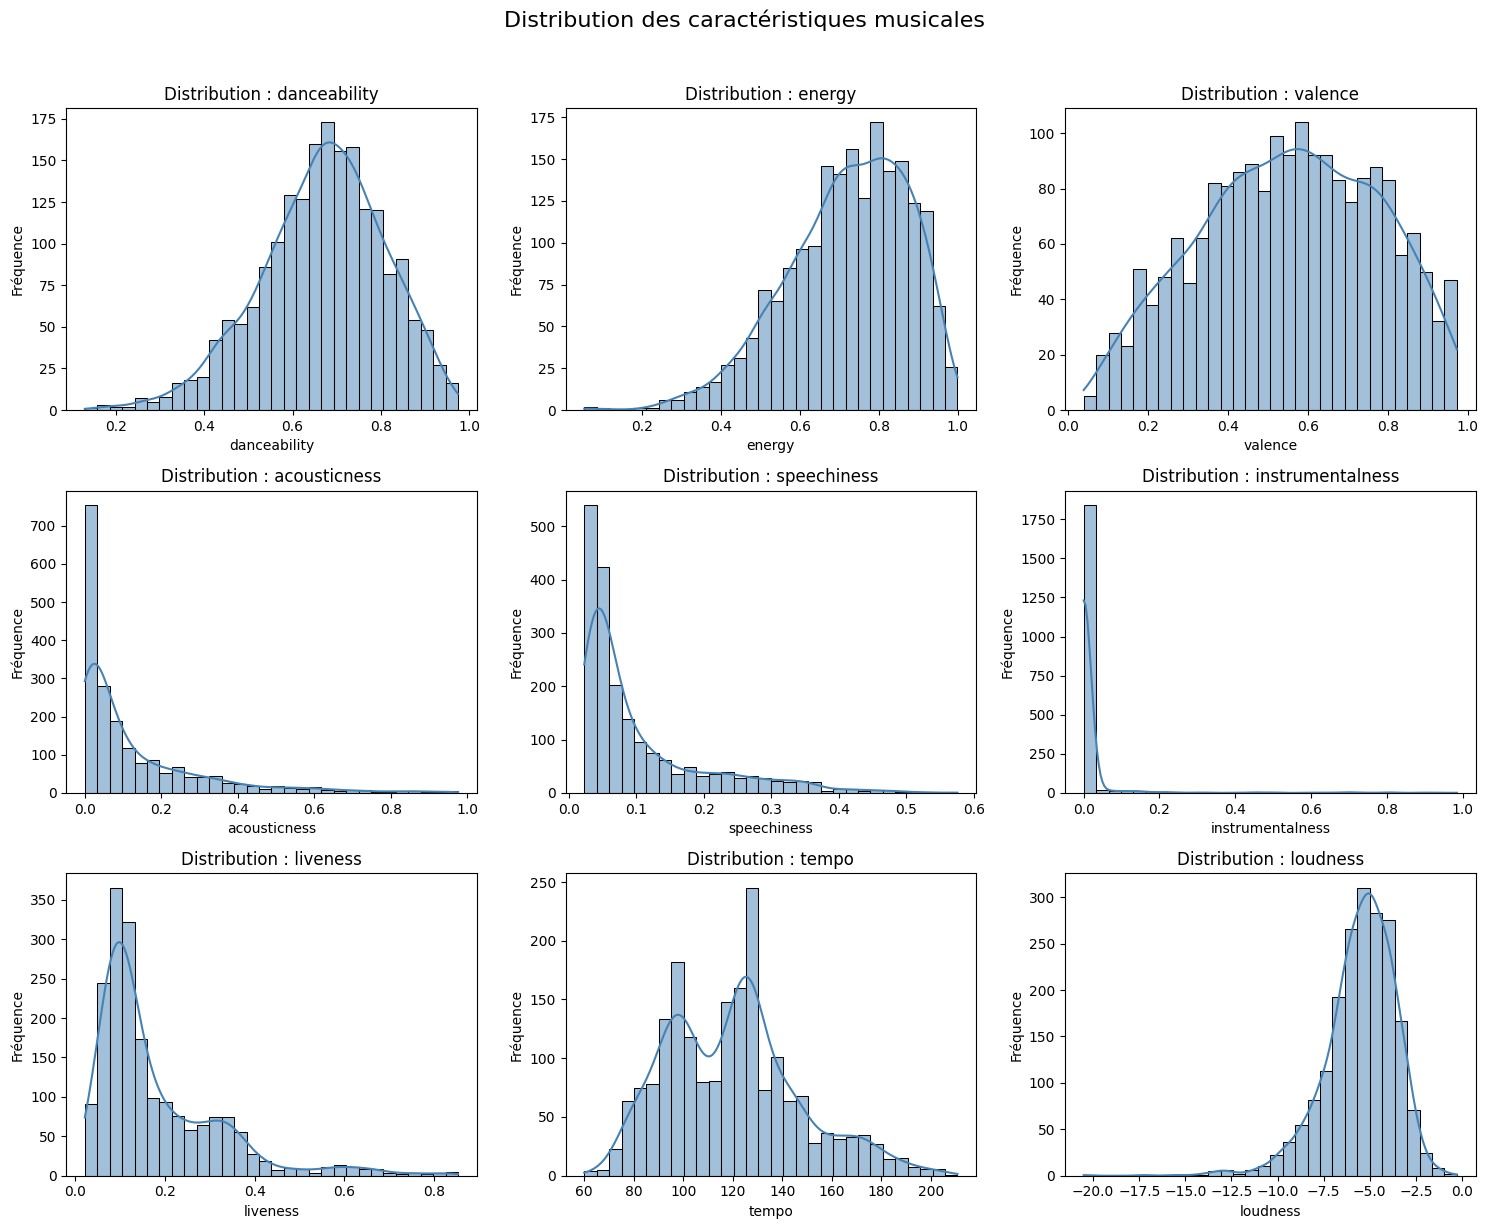

In [33]:
features_to_plot = ['danceability', 'energy', 'valence', 'acousticness',
                    'speechiness', 'instrumentalness', 'liveness', 'tempo', 'loudness']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    sns.histplot(df[feat], kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribution : {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Fréquence')
plt.suptitle('Distribution des caractéristiques musicales', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Ces histogrammes montrent comment les valeurs sont réparties pour chaque caractéristique. Par exemple on voit que la majorité des morceaux ont une danceabilité entre 0.5 et 0.8, et que presque tous les morceaux ont une instrumentalness proche de 0 ce qui veut dire qu'ils ont des paroles.

### 2. Popularité des morceaux par genre (Boxplot)

/tmp/ipykernel_25441/2126982876.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz2, x='genre', y='popularity', order=order, palette='Set2')


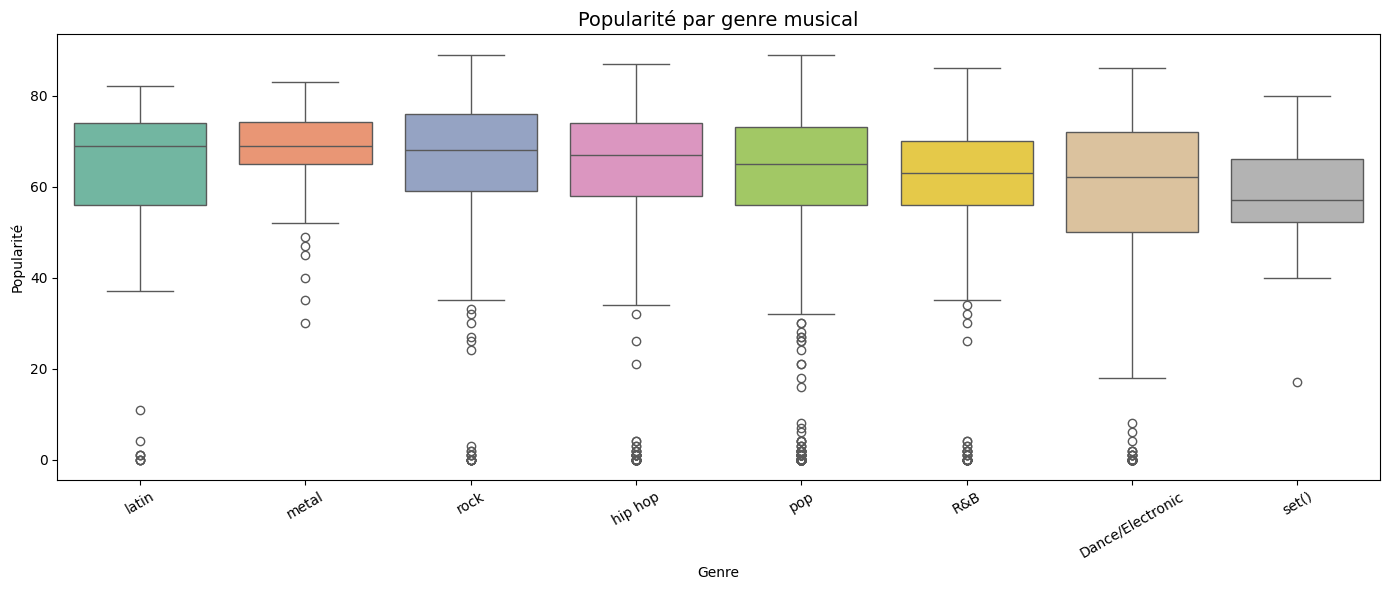

In [34]:
top8_genres = df_exploded['genre'].value_counts().head(8).index
df_viz2 = df_exploded[df_exploded['genre'].isin(top8_genres)]
plt.figure(figsize=(14, 6))
order = df_viz2.groupby('genre')['popularity'].median().sort_values(ascending=False).index
sns.boxplot(data=df_viz2, x='genre', y='popularity', order=order, palette='Set2')
plt.title('Popularité par genre musical', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Popularité')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Ce boxplot permet de comparer la popularité entre les genres. On voit que le pop a une médiane assez haute par rapport aux autres genres. Il y a aussi beaucoup de morceaux avec des scores très variés dans chaque genre.

### 3. Relation entre durée d'un morceau et sa popularité (Scatter plot)

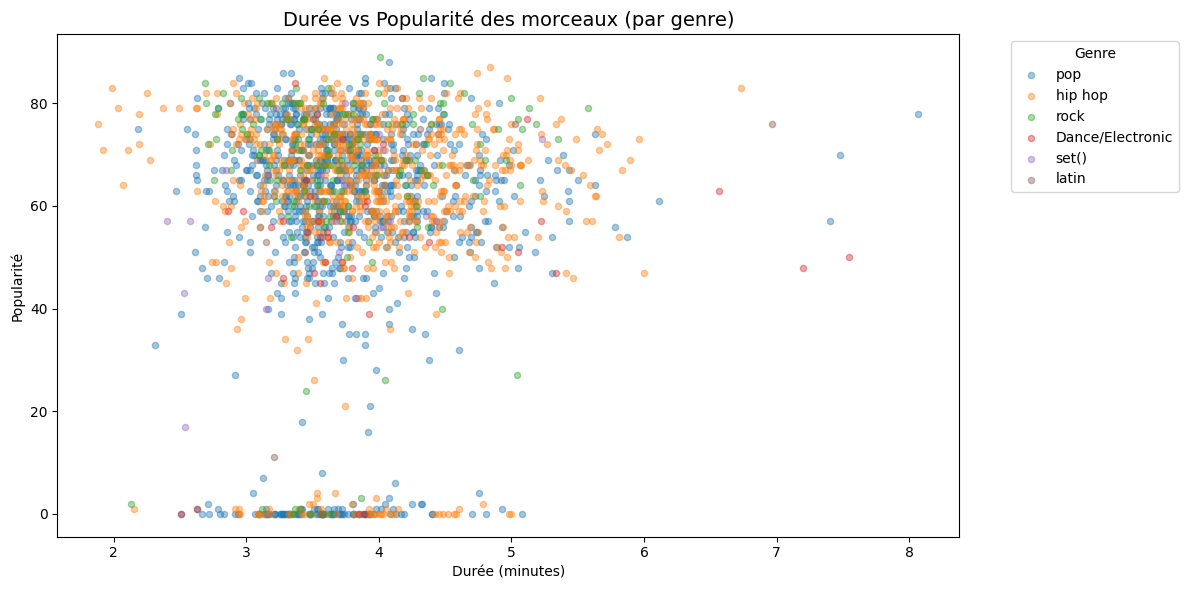

In [35]:
df['duration_min'] = df['duration_ms'] / 60000
df['main_genre']   = df['genre'].str.split(',').str[0].str.strip()
top6_main  = df['main_genre'].value_counts().head(6).index
df_scatter = df[df['main_genre'].isin(top6_main)]
plt.figure(figsize=(12, 6))
palette = sns.color_palette('tab10', n_colors=6)
for i, genre in enumerate(top6_main):
    subset = df_scatter[df_scatter['main_genre'] == genre]
    plt.scatter(subset['duration_min'], subset['popularity'],
                alpha=0.4, label=genre, color=palette[i], s=20)
plt.title('Durée vs Popularité des morceaux (par genre)', fontsize=14)
plt.xlabel('Durée (minutes)')
plt.ylabel('Popularité')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

On voit sur ce graphique qu'il n'y a pas vraiment de relation entre la durée d'un morceau et sa popularité. Les points sont dispersés partout sans tendance claire. Des morceaux courts et des morceaux longs peuvent tous les deux avoir des scores élevés.

### 4. Comparaison de la popularité entre artistes (Bar chart)

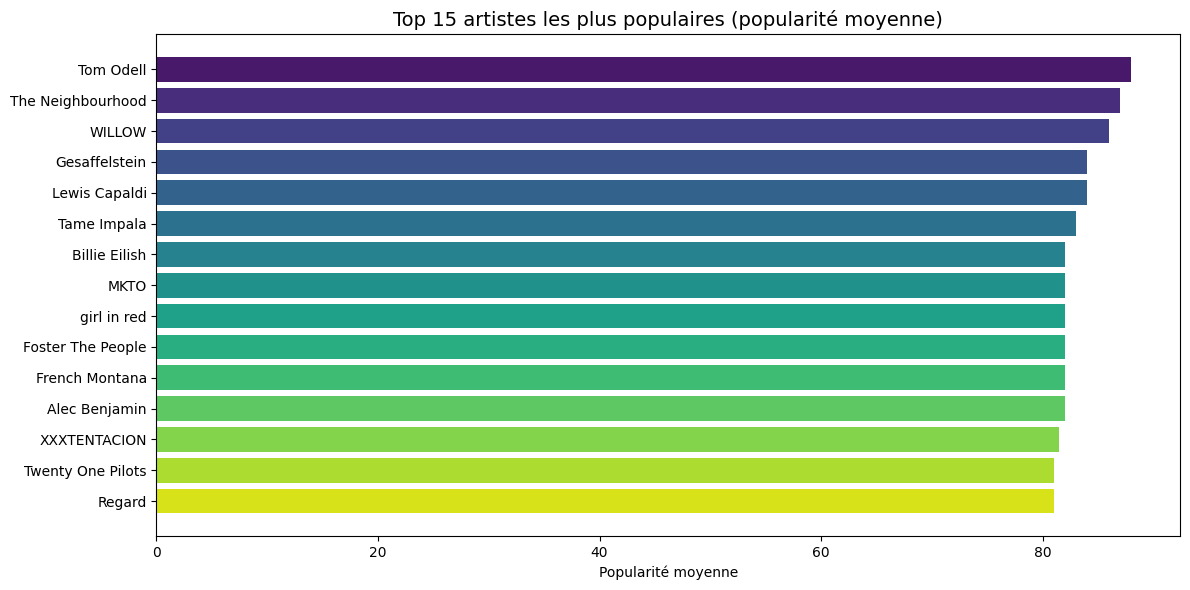

In [36]:
top15_artists = df.groupby('artist')['popularity'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12, 6))
colors = sns.color_palette('viridis', len(top15_artists))
plt.barh(top15_artists.index[::-1], top15_artists.values[::-1], color=colors[::-1])
plt.title('Top 15 artistes les plus populaires (popularité moyenne)', fontsize=14)
plt.xlabel('Popularité moyenne')
plt.tight_layout()
plt.show()

Ce graphique montre les 15 artistes avec la plus haute popularité moyenne. Tom Odell est en tête avec presque 88 de moyenne, suivi de The Neighbourhood. On remarque que les artistes du top ont tous des scores très proches les uns des autres.

### 5. Évolution de la popularité au fil du temps (Line plot)

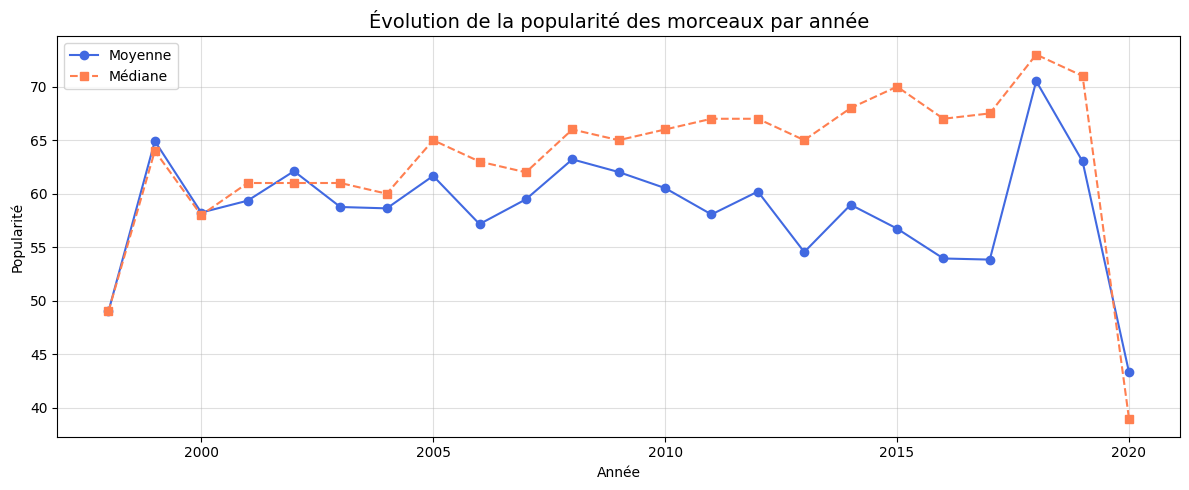

In [37]:
yearly = df.groupby('year')['popularity'].agg(['mean', 'median'])
plt.figure(figsize=(12, 5))
plt.plot(yearly.index, yearly['mean'],   marker='o', label='Moyenne', color='royalblue')
plt.plot(yearly.index, yearly['median'], marker='s', linestyle='--', label='Médiane', color='coral')
plt.title('Évolution de la popularité des morceaux par année', fontsize=14)
plt.xlabel('Année')
plt.ylabel('Popularité')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

La courbe montre une tendance à la hausse de la popularité au fil des années. Les morceaux récents ont généralement des scores plus élevés. Cela peut s'expliquer par le fait que Spotify donne plus de visibilité aux sorties récentes.

### 6. Distribution du tempo par genre (Boxplot)

/tmp/ipykernel_25441/1619732426.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz6, x='genre', y='tempo', order=order_tempo, palette='coolwarm')


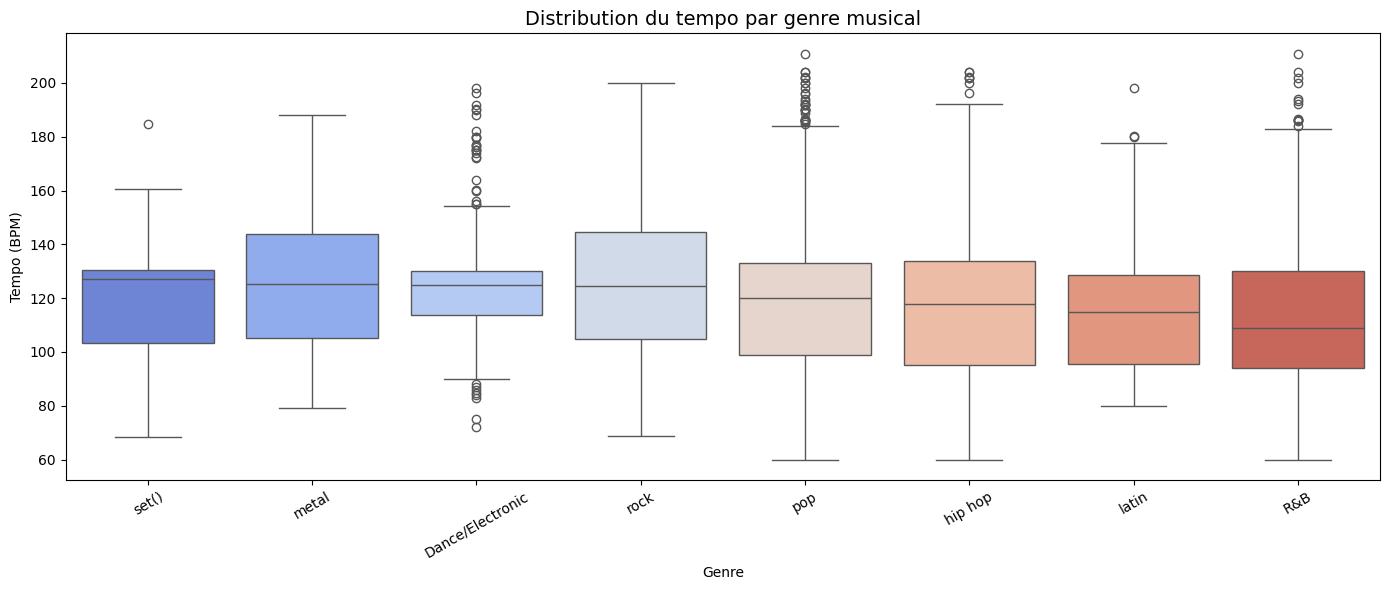

In [38]:
df_viz6 = df_exploded[df_exploded['genre'].isin(top8_genres)]
plt.figure(figsize=(14, 6))
order_tempo = df_viz6.groupby('genre')['tempo'].median().sort_values(ascending=False).index
sns.boxplot(data=df_viz6, x='genre', y='tempo', order=order_tempo, palette='coolwarm')
plt.title('Distribution du tempo par genre musical', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Tempo (BPM)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

On voit que le Dance/Electronic a tendance à avoir des tempos plus rapides, tandis que le Folk/Acoustic a des tempos plus lents et plus variés. Le hip hop est aussi plutôt rapide en général.

### 7. Corrélation entre les caractéristiques des morceaux (Heatmap)

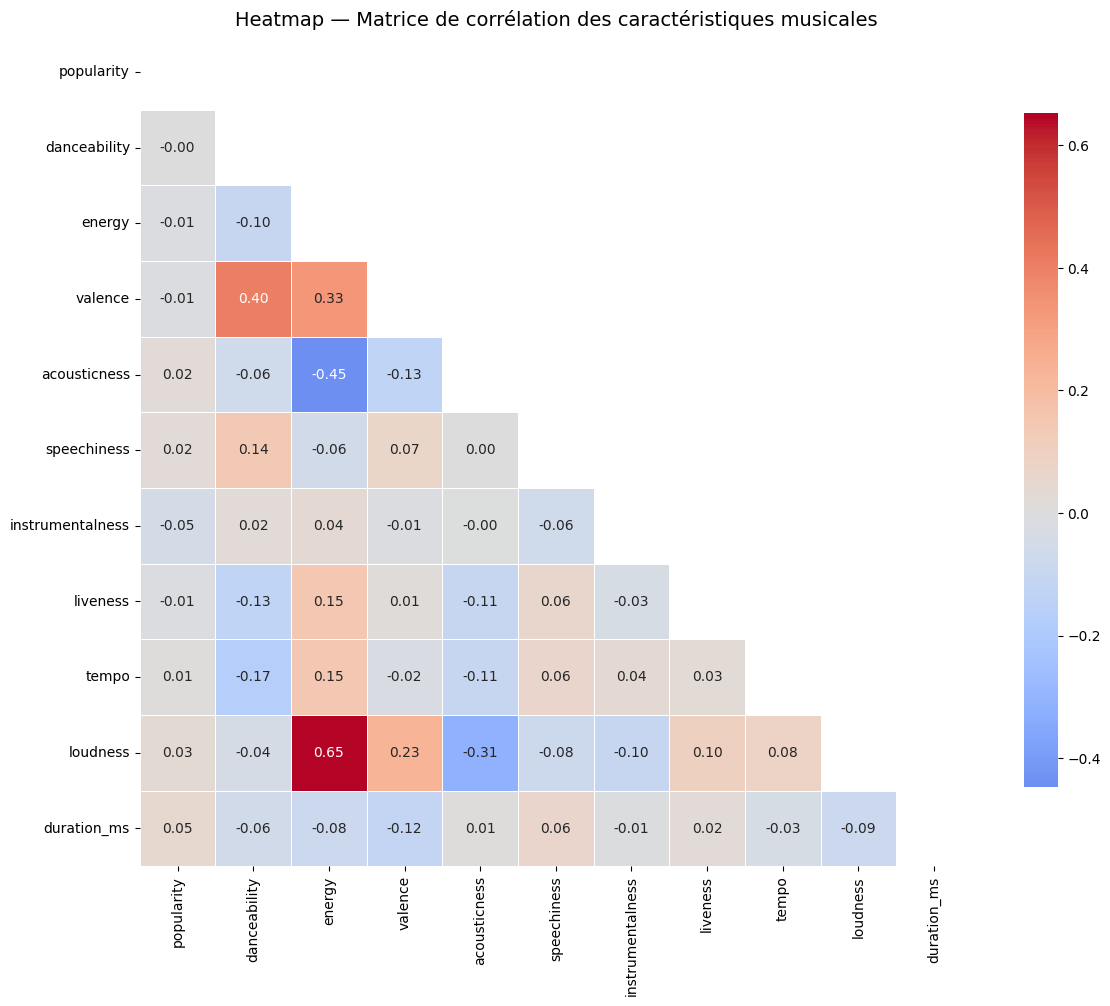

In [39]:
corr_features = ['popularity', 'danceability', 'energy', 'valence', 'acousticness',
                 'speechiness', 'instrumentalness', 'liveness', 'tempo', 'loudness', 'duration_ms']
corr_matrix = df[corr_features].corr()
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Heatmap — Matrice de corrélation des caractéristiques musicales', fontsize=14)
plt.tight_layout()
plt.show()

La heatmap révèle quelques corrélations intéressantes. L'énergie et la loudness sont très liées entre elles, ce qui est logique car les morceaux intenses sont souvent plus forts. A l'inverse l'énergie et l'acousticness sont opposées, un morceau acoustique est rarement intense. On voit aussi que la danceabilité et la valence sont liées, les morceaux dansants ont tendance à être plus joyeux.

### 8. Exploration des morceaux avec des valeurs extrêmes (Scatter + Boxplot)

In [40]:
def flag_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)

df['outlier_duration'] = flag_outliers(df['duration_ms'])
df['outlier_energy']   = flag_outliers(df['energy'])
df['is_outlier'] = df['outlier_duration'] | df['outlier_energy']
print(f"Morceaux avec valeurs extrêmes : {df['is_outlier'].sum()}")
print('\nExemples :')
df[df['is_outlier']][['song', 'artist', 'duration_ms', 'energy', 'popularity']].head(10)

Morceaux avec valeurs extrêmes : 83

Exemples :


,song,artist,duration_ms,energy,popularity
24,I Turn To You,Melanie C,352173,0.803,54
25,Take A Look Around,Limp Bizkit,321040,0.852,72
28,The Time Is Now,Moloko,318280,0.743,54
87,Bag Lady,Erykah Badu,348893,0.416,54
88,You Sang To Me,Marc Anthony,347106,0.894,56
97,Higher,Creed,316733,0.830,69
102,Stan,Eminem,404106,0.768,83
124,You Rock My World,Michael Jackson,337733,0.673,64
129,One More Time,Daft Punk,320357,0.697,76
140,Another Chance,Roger Sanchez,452906,0.820,50


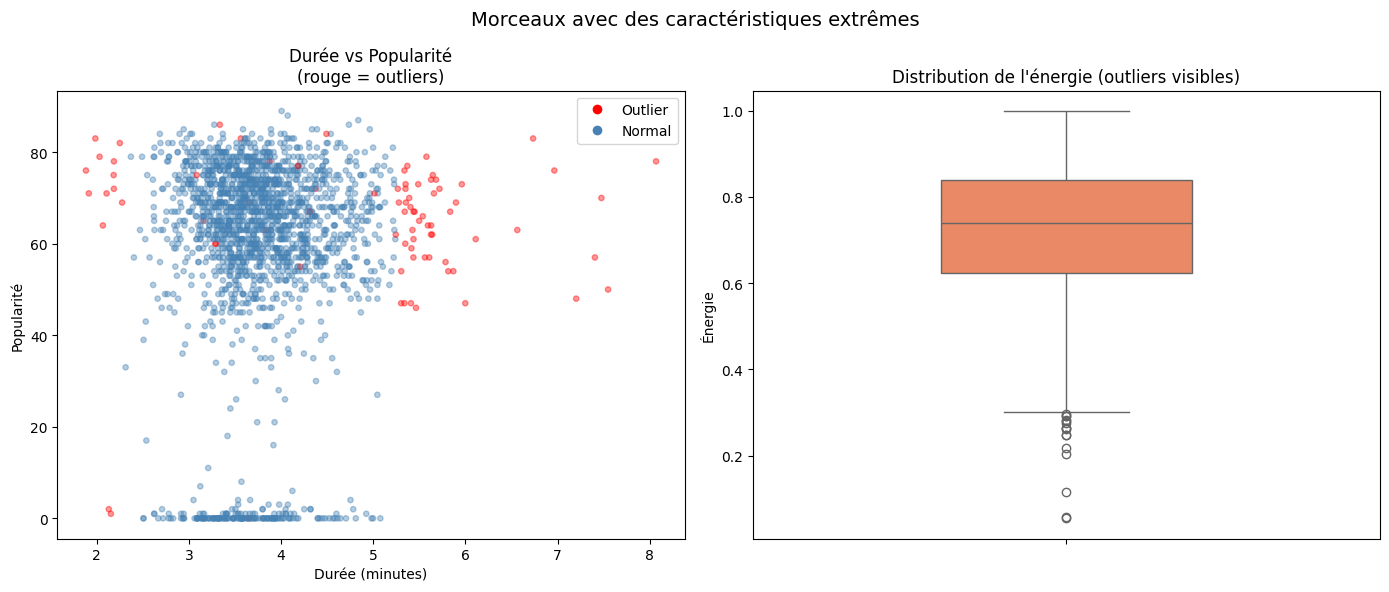

In [41]:
from matplotlib.lines import Line2D
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_map = df['is_outlier'].map({True: 'red', False: 'steelblue'})
axes[0].scatter(df['duration_ms'] / 60000, df['popularity'], c=colors_map, alpha=0.4, s=15)
axes[0].set_title('Durée vs Popularité\n(rouge = outliers)')
axes[0].set_xlabel('Durée (minutes)')
axes[0].set_ylabel('Popularité')
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='red',       label='Outlier', markersize=8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',  label='Normal',  markersize=8)
]
axes[0].legend(handles=legend_elements)
sns.boxplot(y=df['energy'], ax=axes[1], color='coral', width=0.4)
axes[1].set_title("Distribution de l'énergie (outliers visibles)")
axes[1].set_ylabel('Énergie')
plt.suptitle('Morceaux avec des caractéristiques extrêmes', fontsize=14)
plt.tight_layout()
plt.show()

Les points rouges sur le graphique représentent les morceaux qui ont des valeurs extrêmes en termes de durée ou d'énergie. On constate qu'il y en a assez peu et que certains de ces morceaux ont quand même des scores de popularité corrects, donc avoir une caractéristique extrême ne nuit pas forcément au succès.